<a href="https://colab.research.google.com/github/GYULEE55/Breast-cancer_statistical_analysis/blob/main/%EC%9C%A0%EB%B0%A9%EC%95%94_%EB%8D%B0%EC%9D%B4%ED%84%B0%20%EC%A0%84%EC%B2%98%EB%A6%AC%20%EB%B0%8F%20%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#유방암 데이터 분석

In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=58ac98dd614cecd6b143cea33041a814ea8a41fe5969cdc15be1b0c188a553ee
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126281 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

In [ ]:
# ======================================
# ① 한글 글꼴 설치 (Nanum + Noto)
# ======================================
!apt-get install -y fonts-nanum fonts-noto-cjk

# ======================================
# ② matplotlib 캐시 삭제 (중요!)
# ======================================
import shutil, os
matplotlib_dir = os.path.join(os.path.expanduser("~"), ".cache", "matplotlib")
shutil.rmtree(matplotlib_dir, ignore_errors=True)

# ======================================
# ③ 글꼴 캐시 재생성 및 폰트 경로 설정
# ======================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess

subprocess.run(['fc-cache', '-fv'], stdout=subprocess.PIPE)

# 시스템 내 NanumGothic 경로 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 36 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 2s (31.0 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 126346 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib -f

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 36 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/opentype: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/opentype/noto: caching, new cache contents: 30 fonts, 0 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/opentype: skipping, looped directory detected
/usr/share/fonts/truetyp

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
plt.rc("font", family = "NanumGothic")
file_path ='/content/drive/MyDrive/세미1차/SEER Breast Cancer Dataset(복사본) .csv'
df= pd.read_csv(file_path)

In [ ]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


#데이터1 전처리


##ER/PR 분류

In [ ]:
def combine_status(row):
    if row['Estrogen Status'] == 'Positive' and row['Progesterone Status'] == 'Positive':
        return 'Both_Positive'
    elif row['Estrogen Status'] == 'Negative' and row['Progesterone Status'] == 'Negative':
        return 'Both_Negative'
    elif row['Estrogen Status'] == 'Negative' and row['Progesterone Status'] == 'Positive':
        return 'PG_positive'
    elif row['Estrogen Status'] == 'Positive' and row['Progesterone Status'] == 'Negative':
        return 'ES_positive'
    else:
        return 'Other'

df['Combined Status'] = df.apply(combine_status, axis=1)

In [ ]:
remove_condition = (
    (df['Estrogen Status'] == 'Negative') & (df['Progesterone Status'] == 'Positive')  # PG_positive 해당
) | (
    (df['Estrogen Status'] == 'Positive') & (df['Progesterone Status'] == 'Negative')  # ES_positive 해당
)

# 조건에 해당하는 행을 제외한 새로운 DataFrame 생성
df_filtered = df[~remove_condition].copy()  # .copy()는 안전하게 복사본을 만듦

# (선택) 'Combined Status' 열을 다시 계산하거나 확인 (필요 시)
df_filtered['Combined Status'] = df_filtered.apply(combine_status, axis=1)

In [ ]:
df_filtered.describe()# 이게 수정되어서 전체 테이블이 됨

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000
mean,53.803728,30.124541,14.390850,4.110138,71.389438
std,9.005124,20.965334,8.134829,5.101984,22.613093
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,24.000000,14.000000,2.000000,73.000000
75%,61.000000,37.000000,19.000000,5.000000,89.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


##LNR분류

In [ ]:
def calc_positive_rate(row):
    if row['Regional Node Examined'] == 0:
        return np.nan
    else:
        return (row['Reginol Node Positive'] / row['Regional Node Examined']) * 100  # 오타 수정: Reginol -> Regional

# 'Positive Rate' 열 생성
df_filtered['Positive Rate'] = df_filtered.apply(calc_positive_rate, axis=1)

def positive_rate_group(rate):
    if pd.isnull(rate):
        return np.nan
    elif rate <= 65:
        return 'Low/medium'
    else:
        return 'High'

# 'Positive Rate Group' 열 생성
df_filtered['Positive Rate Group'] = df_filtered['Positive Rate'].apply(positive_rate_group)
df_filtered['Positive Rate Group'].value_counts()

,count
Positive Rate Group,
Low/medium,2980
High,561


##나이

In [ ]:
def age_group(Age):
    if pd.isnull(Age):
        return np.nan
    elif Age < 50:
        return '50세 이하'
    elif 50 <= Age <= 59:
        return '50대'
    elif 60 <= Age <= 69:
        return '60대'
    else:
        return '그 외'

df_filtered['age_group']=df['Age'].apply(age_group)
df_filtered['age_group'].value_counts()

,count
age_group,
50세 이하,1234
50대,1190
60대,1117


##Race

In [ ]:
def race_group(Race ):
    if pd.isnull(Race ):
        return np.nan
    elif Race == "White":
        return '백인'
    else:
        return '그 외'

df_filtered['race_group']=df['Race '].apply(race_group)
df_filtered['race_group'].value_counts()

,count
race_group,
백인,3004
그 외,537


##결혼


In [ ]:
def marry_group(Marital_Status):
    if pd.isnull(Marital_Status):
        return np.nan
    elif Marital_Status == "Married (including common law)":
        return '결혼'
    else:
        return '그 외'

df_filtered['marry_group']=df['Marital Status'].apply(marry_group)
df_filtered['marry_group'].value_counts()

,count
marry_group,
결혼,2337
그 외,1204


##T stage

In [ ]:
def T_group(T_Stage):
    if T_Stage == 'T1':
        return '1'
    elif T_Stage == 'T2':
        return '2'
    else:
        return '3/4'

df_filtered['T_group']=df['T Stage '].apply(T_group)
df_filtered['T_group'].value_counts()

,count
T_group,
2,1563
1,1434
3/4,544


##N stage

In [ ]:
def N_group(N_Stage):
    if N_Stage == 'N1':
        return '1'
    elif N_Stage == 'N2':
        return '2'
    else:
        return '3'

df_filtered['N_group']=df['N Stage'].apply(N_group)
df_filtered['N_group'].value_counts()

,count
N_group,
1,2423
2,718
3,400


## 6stage

In [ ]:
def six_group(stage):  # 'stage'로 변경 (또는 'sixth_stage' 등으로)
    if stage == 'IIA':
        return '1'
    elif stage == 'IIB':
        return '2'
    elif stage == 'IIIA':
        return '3'
    elif stage == 'IIIB':
        return '4'
    else:
        return 'IIIC'  # None으로 수정 (null 의미)

# 'grade_group' 열 생성 (df_filtered 사용)
df_filtered['six_group'] = df_filtered['6th Stage'].apply(six_group)
df_filtered['six_group'].value_counts()

,count
six_group,
1,1172
2,1001
3,908
IIIC,400
4,60


##Grade

In [ ]:
def grade_group(stage):  # 'stage'로 변경 (또는 'sixth_stage' 등으로)
    if stage == 'Well differentiated; Grade I':
        return '1'
    elif stage == 'Moderately differentiated; Grade II':
        return '2'
    elif stage in 'Poorly differentiated; Grade III':
        return '3'
    else:
        return '4'  # None으로 수정 (null 의미)

# 'grade_group' 열 생성 (df_filtered 사용)
df_filtered['grade_group'] = df_filtered['Grade'].apply(grade_group)
df_filtered['grade_group'].value_counts()

,count
grade_group,
2,2087
3,938
1,500
4,16


##A Stage


In [ ]:
def A_group(N_Stage):
    if N_Stage == 'Regional':
        return '1'
    else:
        return '2'

df_filtered['A_group']=df['A Stage'].apply(A_group)
df_filtered['A_group'].value_counts()

,count
A_group,
1,3459
2,82


##Tumor Size

In [ ]:
def size_group(Tumor_Size):
    if Tumor_Size < 25:
        return '1'
    elif Tumor_Size < 50:
        return '2'

    else:
        return '3'

df_filtered['size_group']=df['Tumor Size'].apply(size_group)
df_filtered['size_group'].value_counts()

,count
size_group,
1,1780
2,1189
3,572


##ES/PS

In [ ]:
def es_group(N_Stage):
    if N_Stage == 'Positive':
        return '1'
    else:
        return '2'

df_filtered['es_group']=df['Estrogen Status'].apply(es_group)
df_filtered['es_group'].value_counts()

#Estrogen_Status

,count
es_group,
1,3299
2,242


In [ ]:
def ps_group(Progesterone_Status):
    if Progesterone_Status == 'Positive':
        return '3'
    else:
        return '4'

df_filtered['ps_group']=df['Progesterone Status'].apply(ps_group)
df_filtered['ps_group'].value_counts()

,count
ps_group,
3,3299
4,242


##Survival Months

In [ ]:
def sm_group(Tumor_Size):
    if Tumor_Size <= 60:
        return '1'
    elif Tumor_Size <= 80:
        return '2'

    else:
        return '3'

df_filtered['sm_group']=df['Survival Months'].apply(sm_group)
df_filtered['sm_group'].value_counts()

,count
sm_group,
3,1355
1,1103
2,1083


##Status

In [ ]:
def ad_group(N_Stage):
    if N_Stage == 'Alive':
        return '1'
    else:
        return '2'

df_filtered['ad_group']=df['Status'].apply(ad_group)
df_filtered['ad_group'].value_counts()

,count
ad_group,
1,3033
2,508


#데이터2 전처리

In [ ]:
file_path ='/content/drive/MyDrive/세미1차/breast cancer DB2.csv'# 각자의 파일 경로 복
df1= pd.read_csv(file_path)

In [ ]:
df=df1.copy()
df.head()

,Sex,"Race recode (W, B, AI)",Age recode with <30-69,Marital status at diagnosis un,Grade,ER Status,PR Status,HER2,Survival month,Theraphy
0,Female,White,75-79 years,Divorced,Moderately differentiated; Grade II,Positive,Negative,Recode not available,14,No radiation and/or no surgery; unknown if sur...
1,Female,Black,70-74 years,Single (never married),Poorly differentiated; Grade III,Negative,Negative,Negative,12,Radiation after surgery
2,Female,White,70-74 years,Single (never married),Blank(s),Negative,Negative,Negative,59,Radiation after surgery
3,Female,White,60-64 years,Widowed,Unknown,Positive,Negative,Recode not available,81,No radiation and/or no surgery; unknown if sur...
4,Female,White,70-74 years,Widowed,Poorly differentiated; Grade III,Negative,Negative,Recode not available,7,No radiation and/or no surgery; unknown if sur...


In [ ]:
df.info() #데이터 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column                          Non-Null Count    Dtype 
---  ------                          --------------    ----- 
 0   Sex                             1048575 non-null  object
 1   Race recode (W, B, AI)          1048575 non-null  object
 2   Age recode with <30-69          1048575 non-null  object
 3   Marital status at diagnosis un  1048575 non-null  object
 4   Grade                           1048575 non-null  object
 5   ER Status                       1048575 non-null  object
 6   PR Status                       1048575 non-null  object
 7   HER2                            1048575 non-null  object
 8   Survival month                  1048575 non-null  object
 9   Theraphy                        1048575 non-null  object
dtypes: object(10)
memory usage: 80.0+ MB


In [ ]:
#열이름 재정립
df = df.rename(columns={          'Sex':'Sex',
                                  'Race recode (W, B, AI)':'Race',
                                 'Age recode with <30-69':'Age',
                                  'Marital status at diagnosis un':'Marital status',
                                  'Survival month':'Survival months'

                                  })
df.head()


,Sex,Race,Age,Marital status,Grade,ER Status,PR Status,HER2,Survival months,Theraphy
0,Female,White,75-79 years,Divorced,Moderately differentiated; Grade II,Positive,Negative,Recode not available,14,No radiation and/or no surgery; unknown if sur...
1,Female,Black,70-74 years,Single (never married),Poorly differentiated; Grade III,Negative,Negative,Negative,12,Radiation after surgery
2,Female,White,70-74 years,Single (never married),Blank(s),Negative,Negative,Negative,59,Radiation after surgery
3,Female,White,60-64 years,Widowed,Unknown,Positive,Negative,Recode not available,81,No radiation and/or no surgery; unknown if sur...
4,Female,White,70-74 years,Widowed,Poorly differentiated; Grade III,Negative,Negative,Recode not available,7,No radiation and/or no surgery; unknown if sur...


In [ ]:
#데이터 전처리

## 생존기간 120보다 큰 거 지움

# Survival months 컬럼을 숫자형으로 변환(혹시 문자열이 있을 경우 대비)
df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# 120개월 초과하는 데이터 제거
df = df[df['Survival months'] <= 120]

# 결과 확인
print(df['Survival months'].describe())
print(f"120개월 초과 데이터가 제거된 후 데이터 개수: {len(df)}")

df.shape

##Race 그룹화


df['Race'].value_counts()

df['Race'].isnull().sum()

def group_race(x):
    if x == "White":
        return "White"
    elif x == "Asian or Pacific Islander":
        return "Asian or Pacific Islander"
    else:
        return "Other"

df['Race_group'] = df['Race'].apply(group_race)

# 결과 확인
print(df['Race_group'].value_counts())
print(df[['Race', 'Race_group']].head(10))

##Age

df['Age'].value_counts()

df['Age'].isnull().sum()

def age_group_from_range(age_str):
    if pd.isnull(age_str):
        return np.nan
    # '90+ years'와 같은 경우 숫자만 추출
    num_part = age_str.split('-')[0].split('+')[0]
    min_age = int(''.join(filter(str.isdigit, num_part)))
    if min_age < 50:
        return '<50'
    elif min_age < 60:
        return '<60'
    else:
        return '>=60'

df['Age_group'] = df['Age'].apply(age_group_from_range)

# 결과 확인
print(df['Age_group'].value_counts())
print(df[['Age', 'Age_group']].drop_duplicates().sort_values('Age'))



## Marital status

df['Marital status'].value_counts()

df['Marital status'].isnull().sum()

def group_marital_status(x):
    if x == "Married (including common law)":
        return "Married"
    elif x == "Single (never married)":
        return "Single"
    else:
        return "Other"

df['Marital_group'] = df['Marital status'].apply(group_marital_status)

# 결과 확인
print(df['Marital_group'].value_counts())
print(df[['Marital status', 'Marital_group']].drop_duplicates())

##Grade

df['Grade'].value_counts()
df['Grade'].isnull().sum()

def group_grade(x):
    if x == "Well differentiated; Grade I":
        return "Grade I"
    elif x == "Moderately differentiated; Grade II":
        return "Grade II"
    elif x == "Poorly differentiated; Grade III":
        return "Grade III"
    elif x == "Undifferentiated; anaplastic; Grade IV":
        return "Grade IV"
    else:
        return "Other"

df['Grade_group'] = df['Grade'].apply(group_grade)

# 결과 확인
print(df['Grade_group'].value_counts())
print(df[['Grade', 'Grade_group']].drop_duplicates())

## Estrogen_Status



df['ER Status'].value_counts()

df['ER Status'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['ER_group'] = df['ER Status'].apply(group_er_status)

# 결과 확인
print(df['ER_group'].value_counts())
print(df[['ER Status', 'ER_group']].drop_duplicates())



##Progesterone_Status

df['PR Status'].value_counts()

df['PR Status'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['PR_group'] = df['PR Status'].apply(group_er_status)

# 결과 확인
print(df['PR_group'].value_counts())
print(df[['PR Status', 'PR_group']].drop_duplicates())



## HER2

df['HER2'].value_counts()

df['HER2'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['HER2'] = df['HER2'].apply(group_er_status)

# 결과 확인
print(df['HER2'].value_counts())
print(df[['HER2', 'HER2']].drop_duplicates())



##therapy

def group_radiation(x):
    if x == "No radiation and/or no surgery; unknown if surgery and/or radiation given":
        return "N Radiation"
    elif x == "Intraoperative radiation":
        return "Other"
    else:
        return "Y Radiation"

df['Radiation_group'] = df['Theraphy'].apply(group_radiation)

# 결과 확인
print(df['Radiation_group'].value_counts())
print(df[['Theraphy', 'Radiation_group']].drop_duplicates())


count    692838.000000
mean         50.969895
std          34.649969
min           0.000000
25%          20.000000
50%          47.000000
75%          79.000000
max         120.000000
Name: Survival months, dtype: float64
120개월 초과 데이터가 제거된 후 데이터 개수: 692838
Race_group
White                        549365
Asian or Pacific Islander     73713
Other                         69760
Name: count, dtype: int64
     Race Race_group
0   White      White
1   Black      Other
2   White      White
3   White      White
4   White      White
6   White      White
7   White      White
9   White      White
11  White      White
12  White      White
Age_group
>=60    430997
<60     139934
<50     121907
Name: count, dtype: int64
                Age Age_group
76580   01-04 years       <50
372859  05-09 years       <50
331927  10-14 years       <50
51571   15-19 years       <50
10851   20-24 years       <50
7778    25-29 years       <50
3310    30-34 years       <50
181     35-39 years       <50
9       40-44 ye

#시각화

##시각화 1-1

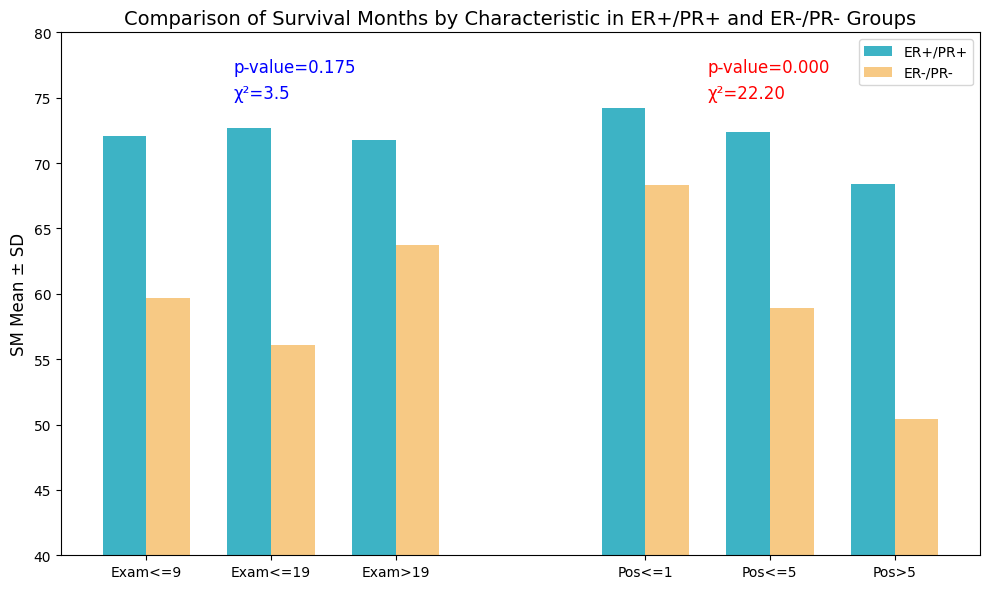

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정 (사용자 제공 데이터 기반)
categories_exam = ['Exam<=9', 'Exam<=19', 'Exam>19']
values_er_exam = [72.1, 72.7, 71.8]  # ER+/PR+ for Exam
values_er_neg_exam = [59.7, 56.1, 63.7]  # ER-/PR- for Exam

categories_pos = ['Pos<=1', 'Pos<=5', 'Pos>5']
values_er_pos = [74.2, 72.4, 68.4]  # ER+/PR+ for Pos
values_er_neg_pos = [68.3, 58.9, 50.4]  # ER-/PR- for Pos

# 인덱스 생성
x_exam_index = np.arange(len(categories_exam))
x_pos_index = np.arange(len(categories_pos))

bar_width = 0.35  # 바 너비

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# Regional Node Examined 바
ax.bar(x_exam_index - bar_width/2, values_er_exam, bar_width, label='ER+/PR+', color='#3db3c5')
ax.bar(x_exam_index + bar_width/2, values_er_neg_exam, bar_width, label='ER-/PR-', color='#f7c984')

# Regional Node Positive 바 (오른쪽으로 이동)
offset = len(categories_exam) + 1  # 두 그룹 사이 간격
ax.bar(x_pos_index - bar_width/2 + offset, values_er_pos, bar_width, color='#3db3c5')
ax.bar(x_pos_index + bar_width/2 + offset, values_er_neg_pos, bar_width, color='#f7c984')

# Exam 추가
ax.text(0.7, 77, 'p-value=0.175', color='blue', fontsize=12)
ax.text(0.7, 75, 'χ²=3.5', color='blue', fontsize=12)

# Postive그룹
ax.text(offset + 0.5, 77, 'p-value=0.000', color='red', fontsize=12)
ax.text(offset + 0.5, 75, 'χ²=22.20', color='red', fontsize=12)


# 레이블 및 설정
ax.set_ylabel('SM Mean ± SD', fontsize=12)
ax.set_title('Comparison of Survival Months by Characteristic in ER+/PR+ and ER-/PR- Groups', fontsize=14)
ax.set_xticks(np.concatenate((x_exam_index, x_pos_index + offset)))
ax.set_xticklabels(categories_exam + categories_pos, rotation=0)
ax.legend()
ax.set_ylim(40, 80)

plt.tight_layout()
plt.show()



## 시각화1-2

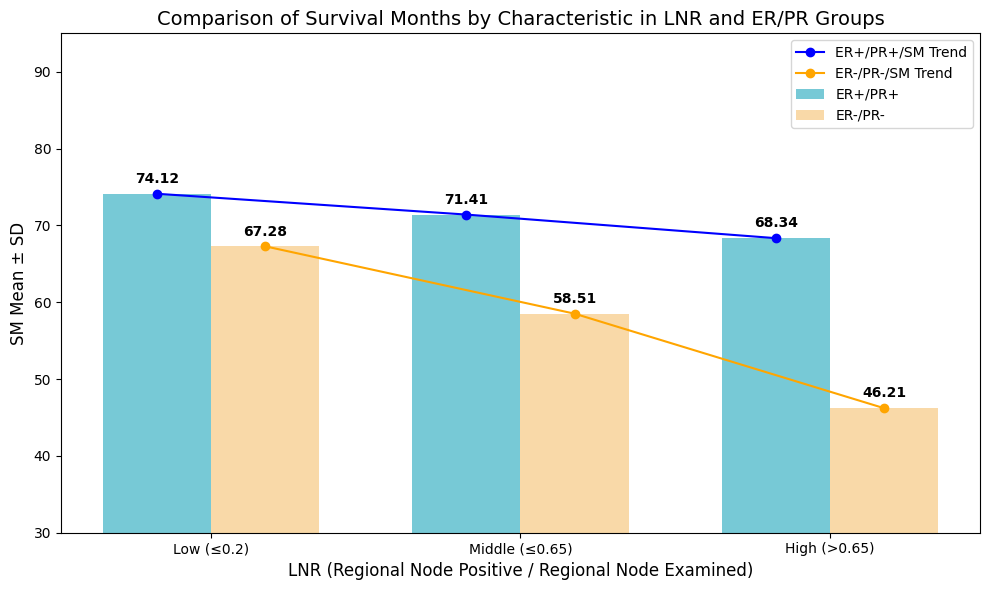

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정 (이전 대화 기반)
categories = ['Low (≤0.2)', 'Middle (≤0.65)', 'High (>0.65)']

# ER+/PR+ 데이터
erpr_pos_sm_mean = [74.12, 71.41, 68.34]

# ER-/PR- 데이터
erpr_neg_sm_mean = [67.28, 58.51, 46.21]

# x축 위치
x = np.arange(len(categories))
bar_width = 0.35  # 바 너비

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# ER+/PR+ 바 (에러 바 제거)
bars1 = ax.bar(x - bar_width/2, erpr_pos_sm_mean, bar_width, label='ER+/PR+', color='#3db3c5', alpha=0.7)

# ER-/PR- 바 (에러 바 제거)
bars2 = ax.bar(x + bar_width/2, erpr_neg_sm_mean, bar_width, label='ER-/PR-', color='#f7c984', alpha=0.7)

# ER+/PR+ 그룹에 선과 마커 추가 (평균값 연결)
ax.plot(x - bar_width/2, erpr_pos_sm_mean, marker='o', linestyle='-', color='blue', label='ER+/PR+/SM Trend')

# ER-/PR- 그룹에 선과 마커 추가 (평균값 연결)
ax.plot(x + bar_width/2, erpr_neg_sm_mean, marker='o', linestyle='-', color='orange', label='ER-/PR-/SM Trend')

# 바 위에 숫자 표시 (평균값)
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 레이블 및 설정
ax.set_xlabel('LNR (Regional Node Positive / Regional Node Examined)', fontsize=12)
ax.set_ylabel('SM Mean ± SD', fontsize=12)
ax.set_title('Comparison of Survival Months by Characteristic in LNR and ER/PR Groups', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)  # x축 레이블 수평
ax.legend()
ax.set_ylim(30, 95)  # y축 범위 조정 (라벨 공간 확보)

plt.tight_layout()
plt.show()


##시각화 2-1


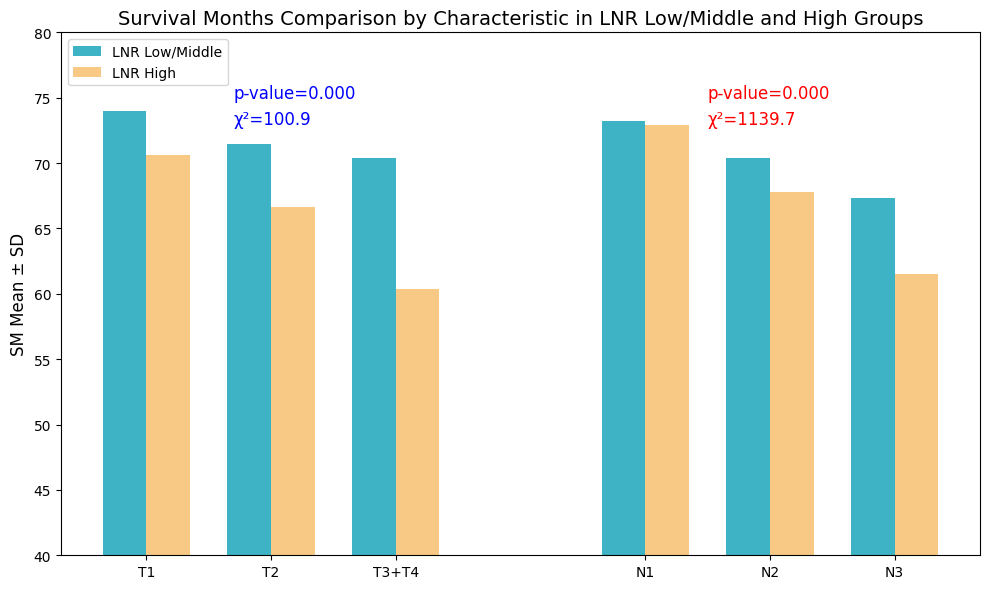

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정 (새로운 사용자 제공 데이터 기반)
categories_t_stage = ['T1', 'T2', 'T3+T4']
values_low_middle_t = [74.00, 71.45, 70.41]  # LNR Low/Middle for T Stage
values_high_t = [70.62, 66.62, 60.37]  # LNR High for T Stage

categories_n_stage = ['N1', 'N2', 'N3']
values_low_middle_n = [73.20, 70.37, 67.29]  # LNR Low/Middle for N Stage
values_high_n = [72.93, 67.82, 61.53]  # LNR High for N Stage

# 인덱스 생성
x_t_stage_index = np.arange(len(categories_t_stage))
x_n_stage_index = np.arange(len(categories_n_stage))

bar_width = 0.35  # 바 너비

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# T Stage 바
ax.bar(x_t_stage_index - bar_width/2, values_low_middle_t, bar_width, label='LNR Low/Middle', color='#3db3c5')
ax.bar(x_t_stage_index + bar_width/2, values_high_t, bar_width, label='LNR High', color='#f7c984')

# N Stage 바 (오른쪽으로 이동)
offset = len(categories_t_stage) + 1  # 두 그룹 사이 간격
ax.bar(x_n_stage_index - bar_width/2 + offset, values_low_middle_n, bar_width, color='#3db3c5')
ax.bar(x_n_stage_index + bar_width/2 + offset, values_high_n, bar_width, color='#f7c984')

# p-value와 χ² 주석 추가 (p-value 위, χ² 아래)
# T Stage 그룹
ax.text(0.7, 75, 'p-value=0.000', color='blue', fontsize=12)
ax.text(0.7, 73, 'χ²=100.9', color='blue', fontsize=12)

# N Stage 그룹
ax.text(offset + 0.5, 75, 'p-value=0.000', color='red', fontsize=12)
ax.text(offset + 0.5, 73, 'χ²=1139.7', color='red', fontsize=12)



# 레이블 및 설정
ax.set_ylabel('SM Mean ± SD', fontsize=12)
ax.set_title('Survival Months Comparison by Characteristic in LNR Low/Middle and High Groups', fontsize=14)
ax.set_xticks(np.concatenate((x_t_stage_index, x_n_stage_index + offset)))
ax.set_xticklabels(categories_t_stage + categories_n_stage, rotation=0)
ax.legend(loc='upper left')  # 범례 위치 유지
ax.set_ylim(40, 80)

plt.tight_layout()
plt.show()


## 시각화 2-2

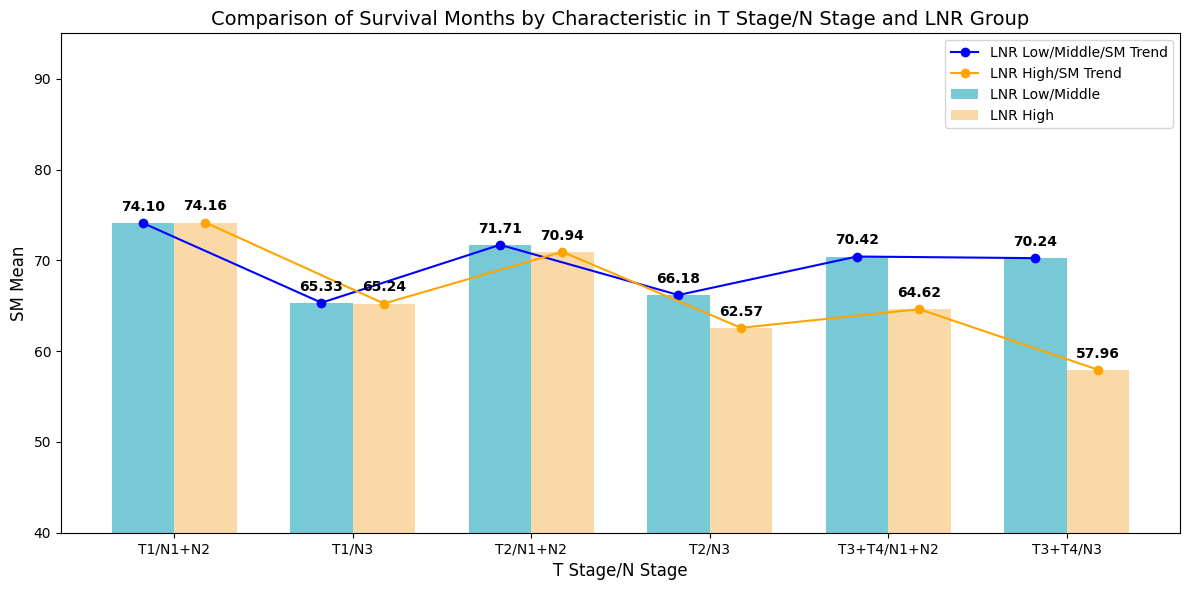

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정
categories = ['T1/N1+N2', 'T1/N3', 'T2/N1+N2', 'T2/N3', 'T3+T4/N1+N2', 'T3+T4/N3']

# LNR Low/Middle 데이터 (SD는 에러 바 제거로 사용 안 함, 하지만 평균만 사용)
lnr_low_middle_mean = [74.10, 65.33, 71.71, 66.18, 70.42, 70.24]

# LNR High 데이터
lnr_high_mean = [74.16, 65.24, 70.94, 62.57, 64.62, 57.96]

# x축 위치
x = np.arange(len(categories))
bar_width = 0.35  # 바 너비

# 그래프 생성
fig, ax = plt.subplots(figsize=(12, 6))  # figsize를 늘려 레이블 겹침 방지

# LNR Low/Middle 바 (에러 바 제거)
bars1 = ax.bar(x - bar_width/2, lnr_low_middle_mean, bar_width, label='LNR Low/Middle', color='#3db3c5', alpha=0.7)

# LNR High 바 (에러 바 제거)
bars2 = ax.bar(x + bar_width/2, lnr_high_mean, bar_width, label='LNR High', color='#f7c984', alpha=0.7)

# LNR Low/Middle 그룹에 선과 마커 추가 (평균값 연결)
ax.plot(x - bar_width/2, lnr_low_middle_mean, marker='o', linestyle='-', color='blue', label='LNR Low/Middle/SM Trend')

# LNR High 그룹에 선과 마커 추가 (평균값 연결)
ax.plot(x + bar_width/2, lnr_high_mean, marker='o', linestyle='-', color='orange', label='LNR High/SM Trend')

# 바 위에 숫자 표시 (평균값)
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 레이블 및 설정
ax.set_xlabel('T Stage/N Stage', fontsize=12)
ax.set_ylabel('SM Mean', fontsize=12)  # SD 제거로 ylabel 수정
ax.set_title('Comparison of Survival Months by Characteristic in T Stage/N Stage and LNR Group', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)  # x축 레이블 수평
ax.legend()
ax.set_ylim(40, 95)  # y축 범위 조정 (라벨 공간 확보)

plt.tight_layout()
plt.show()


##시각화3

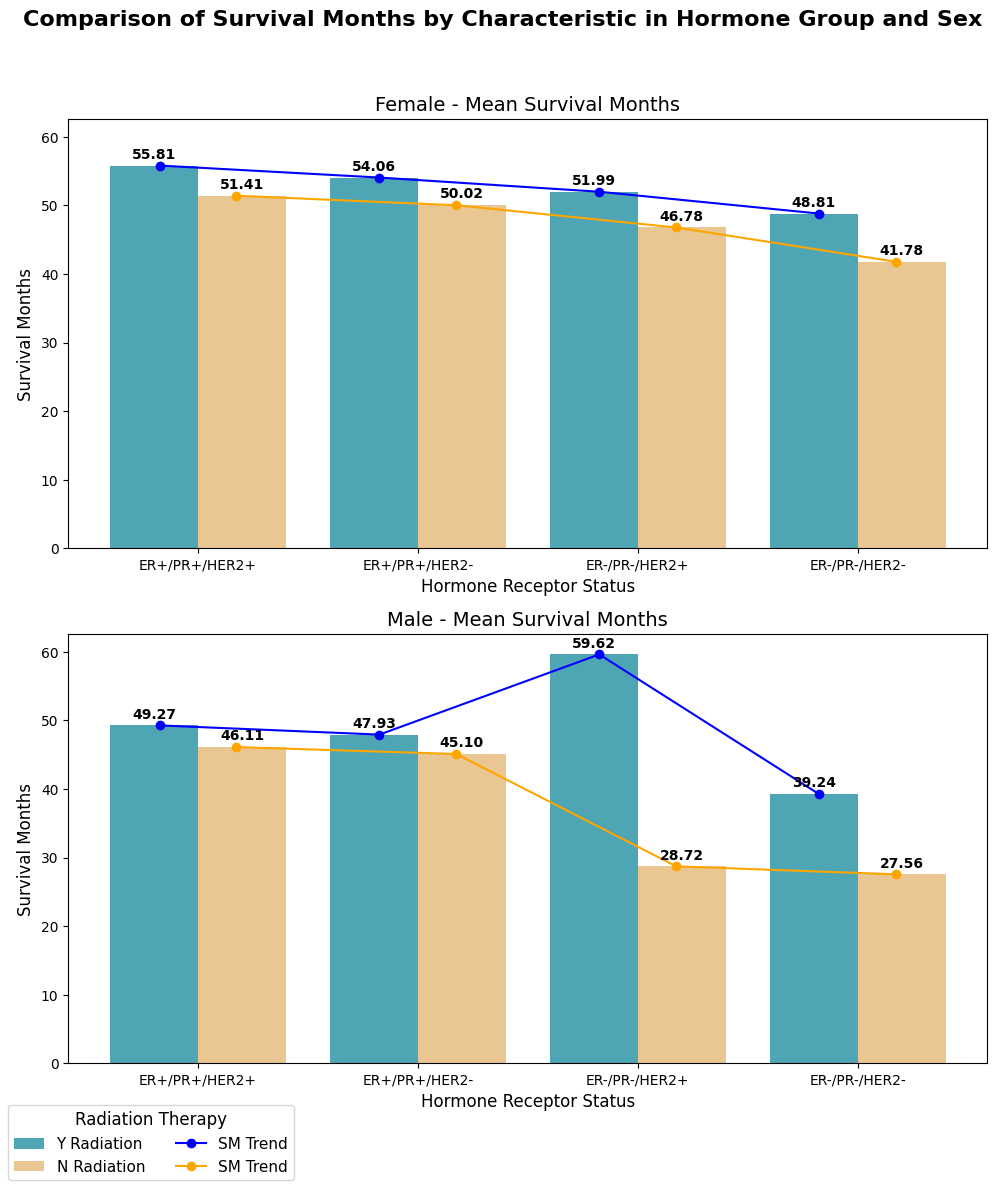

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # x 위치 계산에 필요

# Parse provided data into DataFrames (based on your query)
hormone_groups = [
    'ER+/PR+/HER2+', 'ER+/PR+/HER2-', 'ER-/PR-/HER2+', 'ER-/PR-/HER2-'
]

# Female data
female_data = pd.DataFrame({
    'Hormone_Group': hormone_groups * 2,
    'Therapy_bin': ['Y Radiation'] * 4 + ['N Radiation'] * 4,
    'Mean': [55.81, 54.06, 51.99, 48.81, 51.41, 50.02, 46.78, 41.78],
    'SD': [32.91, 33.90, 33.50, 32.96, 34.93, 34.47, 35.67, 34.83],
    'n': [17104, 166986, 9195, 24404, 18432, 157065, 12479, 28789],
    'pct': [6.88, 67.17, 3.70, 9.82, 7.26, 61.90, 4.92, 11.35],
    'Sex': ['Female'] * 8
})

# Male data
male_data = pd.DataFrame({
    'Hormone_Group': hormone_groups * 2,
    'Therapy_bin': ['Y Radiation'] * 4 + ['N Radiation'] * 4,
    'Mean': [49.27, 47.93, 59.62, 39.24, 46.11, 45.10, 28.72, 27.56],
    'SD': [30.89, 32.49, 42.43, 29.79, 33.36, 32.53, 28.92, 32.82],
    'n': [103, 879, 8, 25, 265, 2218, 18, 50],
    'pct': [0.04, 0.35, 0.003, 0.01, 0.10, 0.87, 0.01, 0.02],
    'Sex': ['Male'] * 8
})

# Combine into summary DataFrame
summary = pd.concat([female_data, male_data]).reset_index(drop=True)

# Hormone order
hormone_order = hormone_groups

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), sharey=True)

# Bar width for line offsets
bar_width = 0.35

# Plot for each sex
for idx, sex in enumerate(['Female', 'Male']):
    subset = summary[summary['Sex'] == sex]
    ax = axes[idx]

    barplot = sns.barplot(
        data=subset,
        x='Hormone_Group',
        y='Mean',
        hue='Therapy_bin',
        order=hormone_order,
        hue_order=['Y Radiation', 'N Radiation'],
        palette={'Y Radiation': '#3db3c5', 'N Radiation': '#f7c984'},
        errorbar='sd',  # Built-in SD error bars
        ax=ax
    )

    # Bar labels (mean values above bars)
    for container in barplot.containers:
        barplot.bar_label(
            container,
            fmt='%.2f',  # Two decimal places
            fontsize=10,
            fontweight='bold',
            label_type='edge',
            padding=3  # Positive padding to place labels above the bars
        )

    # Now add lines and markers within the loop (per subplot)
    # Extract means for Y and N Radiation (assuming LNR Low/Middle = Y, High = N for example; adjust if needed)
    lnr_low_middle_mean = subset[subset['Therapy_bin'] == 'Y Radiation']['Mean'].values
    lnr_high_mean = subset[subset['Therapy_bin'] == 'N Radiation']['Mean'].values

    # x positions for lines (adjusted for bar groups)
    x = np.arange(len(hormone_order))

    # Plot line for LNR Low/Middle (left bars)
    ax.plot(x - bar_width/2, lnr_low_middle_mean, marker='o', linestyle='-', color='blue', label='SM Trend')

    # Plot line for LNR High (right bars)
    ax.plot(x + bar_width/2, lnr_high_mean, marker='o', linestyle='-', color='orange', label='SM Trend')

    # Subplot settings
    ax.set_title(f'{sex} - Mean Survival Months', fontsize=14)
    ax.set_xlabel('Hormone Receptor Status', fontsize=12)
    ax.set_ylabel('Survival Months', fontsize=12)
    ax.tick_params(axis='x', rotation=0)  # Rotate for long labels
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()  # Get from first ax
fig.legend(
    handles,
    labels,
    title='Radiation Therapy',
    loc='lower left',  # 아래쪽 왼쪽으로 변경 (기본 수정)

    ncol=2,
    fontsize=11,
    title_fontsize=12
)

# Overall title and layout
fig.suptitle('Comparison of Survival Months by Characteristic in Hormone Group and Sex', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
